STRUCTURED CREDIT PORTFOLIO ANALYSIS — TRADE FINANCE ENGINE

Liquidity Management & Credit Risk Assessment Framework

**OVERVIEW**:

  This module provides a complete framework for analyzing trade finance portfolios.
  It covers:
    1. Synthetic high-volume portfolio generation (20,000 invoice records)
    2. StructuredCreditEngine — borrowing base calculation with eligibility filters
       and concentration haircuts
    3. Stress Testing — systemic payment delay scenarios
    4. Monte Carlo Simulation — probabilistic default risk quantification
    5. Publication-quality visual dashboard (6-panel)
    6. Executive summary printed to console

**USAGE**:
  python trade_finance_analysis.py

**DEPENDENCIES**:
  pip install pandas numpy matplotlib seaborn scipy

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats
from dataclasses import dataclass, field
from typing import Tuple, Dict, Optional
import time

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — DATA GENERATION
# ─────────────────────────────────────────────────────────────────────────────

def generate_institutional_portfolio(n_records: int = 20_000, seed: int = 42) -> pd.DataFrame:
    """
    Generates a realistic synthetic trade finance portfolio.

    Design choices that mirror real-world distributions:
    - Invoice amounts follow a Gamma distribution (right-skewed, as in practice)
    - Days outstanding are uniform across the 0-119 range
    - Dispute rate set at 1.5% (industry-typical for trade finance)
    - 150 distinct debtors for meaningful concentration analysis

    Parameters
    ----------
    n_records : int
        Number of invoice records to simulate.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Portfolio DataFrame with columns:
        invoice_id, debtor_name, amount, days_outstanding, is_disputed,
        industry, credit_rating, country
    """
    np.random.seed(seed)
    n_debtors = 150
    debtors = [f"Debtor_{i:03d}" for i in range(1, n_debtors + 1)]

    # Additional enrichment columns for deeper analysis
    industries = ["Manufacturing", "Retail", "Energy", "Technology",
                  "Agriculture", "Healthcare", "Construction", "Logistics"]
    ratings = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
    rating_weights = [0.05, 0.10, 0.20, 0.30, 0.20, 0.10, 0.05]
    countries = ["US", "DE", "GB", "FR", "JP", "CN", "CA", "AU", "BR", "SG"]

    # Assign fixed attributes per debtor (consistent across all their invoices)
    debtor_industry = {d: np.random.choice(industries) for d in debtors}
    debtor_rating   = {d: np.random.choice(ratings, p=rating_weights) for d in debtors}
    debtor_country  = {d: np.random.choice(countries) for d in debtors}

    chosen_debtors = np.random.choice(debtors, n_records)

    data = {
        "invoice_id":       np.arange(1, n_records + 1),
        "debtor_name":      chosen_debtors,
        "amount":           np.random.gamma(shape=1.5, scale=6_000, size=n_records),
        "days_outstanding": np.random.randint(0, 120, size=n_records),
        "is_disputed":      np.random.choice([True, False], n_records, p=[0.015, 0.985]),
        "industry":         [debtor_industry[d] for d in chosen_debtors],
        "credit_rating":    [debtor_rating[d]   for d in chosen_debtors],
        "country":          [debtor_country[d]  for d in chosen_debtors],
    }
    df = pd.DataFrame(data)
    df["amount"] = df["amount"].clip(lower=500)   # Minimum invoice floor of $500
    return df


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — STRUCTURED CREDIT ENGINE
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class EngineConfig:
    """Configuration parameters for the StructuredCreditEngine."""
    facility_limit:      float = 150_000_000.0   # Max facility: $150M
    advance_rate:        float = 0.85              # 85% advance on net eligible
    concentration_cap:   float = 0.10              # Max 10% per debtor
    max_days_eligible:   int   = 90                # Invoices aged ≤90 days are eligible
    monte_carlo_iters:   int   = 1_000             # MC simulation iterations
    default_probability: float = 0.03              # 3% idiosyncratic default prob
    stress_max_delay:    int   = 30                # Max delay days in stress test
    stress_step:         int   = 5                 # Step size for stress delay loop


class StructuredCreditEngine:
    """
    Core engine for trade finance credit facility management.

    Responsibilities:
      - Eligibility determination (age and dispute filters)
      - Concentration haircut calculation
      - Borrowing base computation
      - Stress testing under payment delay scenarios
      - Monte Carlo simulation of random default shocks
    """

    def __init__(self, config: Optional[EngineConfig] = None):
        self.cfg = config or EngineConfig()

    # ── Borrowing Base ────────────────────────────────────────────────────────

    def compute_borrowing_base(
        self, df: pd.DataFrame
    ) -> Dict[str, float]:
        """
        Calculates the Borrowing Base (BB) from a portfolio snapshot.

        Steps:
          1. Eligibility filter  — remove aged (>90 days) and disputed invoices
          2. Concentration cap   — haircut any debtor exceeding 10% of eligible pool
          3. Advance rate        — apply 85% advance against net-eligible collateral
          4. Facility cap        — floor at the committed facility limit ($150M)

        Returns
        -------
        dict with keys:
          borrowing_base, gross_eligible, total_haircut,
          bb_before_cap, utilisation_pct, eligible_count, total_count
        """
        cfg = self.cfg
        work = df.copy()

        # Step 1 — Eligibility
        work["is_eligible"] = (
            (work["days_outstanding"] <= cfg.max_days_eligible) &
            (~work["is_disputed"])
        )
        eligible = work[work["is_eligible"]]

        if eligible.empty:
            return {k: 0.0 for k in
                    ["borrowing_base", "gross_eligible", "total_haircut",
                     "bb_before_cap", "utilisation_pct", "eligible_count", "total_count"]}

        gross_eligible = eligible["amount"].sum()

        # Step 2 — Concentration haircut
        max_per_debtor = gross_eligible * cfg.concentration_cap
        debtor_totals  = eligible.groupby("debtor_name")["amount"].sum()
        haircuts       = (debtor_totals - max_per_debtor).clip(lower=0)
        total_haircut  = haircuts.sum()

        # Step 3 & 4 — Advance rate and facility cap
        net_eligible    = gross_eligible - total_haircut
        bb_before_cap   = net_eligible * cfg.advance_rate
        borrowing_base  = min(bb_before_cap, cfg.facility_limit)
        utilisation_pct = (borrowing_base / cfg.facility_limit) * 100

        return {
            "borrowing_base":   borrowing_base,
            "gross_eligible":   gross_eligible,
            "total_haircut":    total_haircut,
            "bb_before_cap":    bb_before_cap,
            "utilisation_pct":  utilisation_pct,
            "eligible_count":   int(eligible.shape[0]),
            "total_count":      int(work.shape[0]),
        }

    # ── Stress Test ───────────────────────────────────────────────────────────

    def run_stress_test(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Simulates systemic payment delays (0 to max_delay days, step 5).

        For each delay increment, all invoices have their days_outstanding
        shifted forward, mimicking a market-wide slowdown in payments.

        Returns
        -------
        pd.DataFrame with columns: Delay_Days, Borrowing_Base,
        Gross_Eligible, Total_Haircut, Utilisation_Pct
        """
        cfg    = self.cfg
        rows   = []
        delays = range(0, cfg.stress_max_delay + 1, cfg.stress_step)

        for delay in delays:
            stressed = df.copy()
            stressed["days_outstanding"] = stressed["days_outstanding"] + delay
            result = self.compute_borrowing_base(stressed)
            rows.append({
                "Delay_Days":       delay,
                "Borrowing_Base":   result["borrowing_base"],
                "Gross_Eligible":   result["gross_eligible"],
                "Total_Haircut":    result["total_haircut"],
                "Utilisation_Pct":  result["utilisation_pct"],
            })

        return pd.DataFrame(rows)

    # ── Monte Carlo ───────────────────────────────────────────────────────────

    def run_monte_carlo(self, df: pd.DataFrame) -> np.ndarray:
        """
        Simulates idiosyncratic default shocks via binomial random draws.

        In each iteration, every invoice independently faces a 3% probability
        of being marked as defaulted (disputed=True), removing it from the
        eligible pool. The resulting borrowing base is recorded.

        Returns
        -------
        np.ndarray of borrowing base values across all iterations.
        """
        cfg     = self.cfg
        results = np.empty(cfg.monte_carlo_iters)

        for i in range(cfg.monte_carlo_iters):
            temp  = df.copy()
            shock = np.random.binomial(1, cfg.default_probability, size=len(temp)).astype(bool)
            temp.loc[shock, "is_disputed"] = True
            results[i] = self.compute_borrowing_base(temp)["borrowing_base"]

        return results

    # ── Risk Metrics ──────────────────────────────────────────────────────────

    def compute_risk_metrics(self, mc_results: np.ndarray) -> Dict[str, float]:
        """Derives key risk metrics from Monte Carlo results."""
        var_5  = np.percentile(mc_results, 5)
        var_1  = np.percentile(mc_results, 1)
        cvar_5 = mc_results[mc_results <= var_5].mean()
        return {
            "mean_bb":   mc_results.mean(),
            "std_bb":    mc_results.std(),
            "var_5pct":  var_5,
            "var_1pct":  var_1,
            "cvar_5pct": cvar_5,
            "min_bb":    mc_results.min(),
            "max_bb":    mc_results.max(),
            "skewness":  float(stats.skew(mc_results)),
            "kurtosis":  float(stats.kurtosis(mc_results)),
        }


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — VISUALISATION DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

# ── Formatters ────────────────────────────────────────────────────────────────
def _millions(x, pos):
    return f"${x/1e6:.1f}M"

def _pct(x, pos):
    return f"{x:.0f}%"


def plot_dashboard(
    engine:    StructuredCreditEngine,
    portfolio: pd.DataFrame,
    base_result: Dict[str, float],
    stress_df:   pd.DataFrame,
    mc_results:  np.ndarray,
    risk_metrics: Dict[str, float],
) -> None:
    """
    Renders a 6-panel publication-quality risk dashboard.

    Panels:
      [0,0] — Liquidity Sensitivity to Payment Delays ("Death Zone" chart)
      [0,1] — Monte Carlo Distribution of Borrowing Base Capacity
      [0,2] — Top 10 Debtor Concentrations (Pre-Haircut)
      [1,0] — Eligibility Waterfall
      [1,1] — Borrowing Base Utilisation by Industry
      [1,2] — Invoice Amount Distribution by Credit Rating
    """

    # ── Styling ───────────────────────────────────────────────────────────────
    DARK_BG     = "#0D1117"
    PANEL_BG    = "#161B22"
    GRID_COLOR  = "#21262D"
    TEXT_LIGHT  = "#E6EDF3"
    TEXT_DIM    = "#8B949E"
    ACCENT_RED  = "#FF4757"
    ACCENT_TEAL = "#1ABC9C"
    ACCENT_BLUE = "#58A6FF"
    ACCENT_ORG  = "#F0A500"
    ACCENT_PURP = "#A855F7"

    plt.rcParams.update({
        "figure.facecolor":  DARK_BG,
        "axes.facecolor":    PANEL_BG,
        "axes.edgecolor":    GRID_COLOR,
        "axes.labelcolor":   TEXT_LIGHT,
        "axes.titlecolor":   TEXT_LIGHT,
        "xtick.color":       TEXT_DIM,
        "ytick.color":       TEXT_DIM,
        "grid.color":        GRID_COLOR,
        "text.color":        TEXT_LIGHT,
        "legend.facecolor":  PANEL_BG,
        "legend.edgecolor":  GRID_COLOR,
        "font.family":       "monospace",
    })

    fig = plt.figure(figsize=(22, 13), facecolor=DARK_BG)
    fig.suptitle(
        "STRUCTURED CREDIT PORTFOLIO  ·  RISK & LIQUIDITY DASHBOARD",
        fontsize=15, fontweight="bold", color=TEXT_LIGHT,
        y=0.97, fontfamily="monospace"
    )
    subtitle = (
        f"Facility: $150M  |  Advance Rate: 85%  |  "
        f"Concentration Cap: 10%  |  Portfolio: {len(portfolio):,} invoices  |  "
        f"Monte Carlo: {engine.cfg.monte_carlo_iters:,} iterations"
    )
    fig.text(0.5, 0.935, subtitle, ha="center", fontsize=9,
             color=TEXT_DIM, fontfamily="monospace")

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32,
                           left=0.05, right=0.97, top=0.90, bottom=0.07)

    axes = [[fig.add_subplot(gs[r, c]) for c in range(3)] for r in range(2)]

    def _style_ax(ax, title, xlabel="", ylabel=""):
        ax.set_facecolor(PANEL_BG)
        ax.set_title(title, fontsize=10, fontweight="bold", pad=10,
                     color=TEXT_LIGHT, fontfamily="monospace")
        ax.set_xlabel(xlabel, fontsize=8, color=TEXT_DIM)
        ax.set_ylabel(ylabel, fontsize=8, color=TEXT_DIM)
        ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6, alpha=0.8)
        ax.tick_params(labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COLOR)

    mm_fmt = FuncFormatter(_millions)

    # ── Panel 1: Liquidity Sensitivity — "Death Zone" ─────────────────────────
    ax = axes[0][0]
    delays = stress_df["Delay_Days"].values
    bbs    = stress_df["Borrowing_Base"].values

    # Shaded "death zone" below 80% utilisation
    critical_level = engine.cfg.facility_limit * 0.80
    ax.fill_between(delays, bbs, critical_level,
                    where=(bbs < critical_level),
                    color=ACCENT_RED, alpha=0.18, label="Death Zone (<80% BB)")
    ax.axhline(critical_level, color=ACCENT_RED, linewidth=1,
               linestyle="--", alpha=0.6, label=f"Critical: ${critical_level/1e6:.0f}M")

    ax.plot(delays, bbs, color=ACCENT_RED, linewidth=2.5,
            marker="o", markersize=7, markerfacecolor=DARK_BG,
            markeredgecolor=ACCENT_RED, markeredgewidth=2, zorder=5)

    # Annotate each point
    for d, b in zip(delays, bbs):
        ax.annotate(f"${b/1e6:.1f}M", (d, b),
                    textcoords="offset points", xytext=(0, 10),
                    fontsize=7, color=TEXT_LIGHT, ha="center",
                    fontfamily="monospace")

    ax.yaxis.set_major_formatter(mm_fmt)
    ax.legend(fontsize=7, loc="upper right")
    _style_ax(ax, "① LIQUIDITY SENSITIVITY  (DELAY STRESS TEST)",
              "Payment Delay (Days)", "Available Credit ($)")

    # ── Panel 2: Monte Carlo — BB Distribution ────────────────────────────────
    ax = axes[0][1]
    rm  = risk_metrics
    var5 = rm["var_5pct"]
    var1 = rm["var_1pct"]

    n, bins, patches = ax.hist(mc_results / 1e6, bins=50,
                                color=ACCENT_TEAL, edgecolor="none", alpha=0.75)
    # Colour the tail red
    for patch, left_edge in zip(patches, bins[:-1]):
        if left_edge < var5 / 1e6:
            patch.set_facecolor(ACCENT_RED)
            patch.set_alpha(0.85)

    # KDE overlay
    kde_x = np.linspace(mc_results.min(), mc_results.max(), 300) / 1e6
    kde   = stats.gaussian_kde(mc_results / 1e6)
    ax2   = ax.twinx()
    ax2.plot(kde_x, kde(kde_x), color=ACCENT_BLUE, linewidth=1.8, alpha=0.9)
    ax2.set_yticks([])
    ax2.set_facecolor(PANEL_BG)
    for spine in ax2.spines.values():
        spine.set_edgecolor(GRID_COLOR)

    ax.axvline(var5 / 1e6, color=ACCENT_ORG, linewidth=1.8, linestyle="--",
               label=f"5% VaR  ${var5/1e6:.1f}M")
    ax.axvline(var1 / 1e6, color=ACCENT_RED, linewidth=1.8, linestyle=":",
               label=f"1% VaR  ${var1/1e6:.1f}M")
    ax.axvline(rm["mean_bb"] / 1e6, color=ACCENT_BLUE, linewidth=1.4,
               linestyle="-", alpha=0.7, label=f"Mean  ${rm['mean_bb']/1e6:.1f}M")

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}M"))
    ax.legend(fontsize=7)
    _style_ax(ax, "② MONTE CARLO  —  BB CAPACITY DISTRIBUTION",
              "Borrowing Base ($M)", "Frequency")

    # ── Panel 3: Top-10 Debtor Concentrations ─────────────────────────────────
    ax = axes[0][2]
    top10 = (portfolio.groupby("debtor_name")["amount"]
             .sum().sort_values(ascending=False).head(10))
    facility_limit = engine.cfg.facility_limit
    cap_line = portfolio["amount"].sum() * engine.cfg.concentration_cap  # rough cap

    colors_bar = [ACCENT_PURP if v > cap_line else ACCENT_BLUE
                  for v in top10.values]
    bars = ax.barh(range(len(top10)), top10.values / 1e6,
                   color=colors_bar, edgecolor="none", height=0.65)

    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([n.replace("Debtor_", "D-") for n in top10.index],
                       fontsize=8, fontfamily="monospace")
    ax.invert_yaxis()

    for bar, val in zip(bars, top10.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"${val/1e6:.1f}M", va="center", fontsize=7.5,
                color=TEXT_LIGHT, fontfamily="monospace")

    legend_patches = [
        mpatches.Patch(color=ACCENT_PURP, label="Exceeds cap (haircut applied)"),
        mpatches.Patch(color=ACCENT_BLUE, label="Within cap"),
    ]
    ax.legend(handles=legend_patches, fontsize=7, loc="lower right")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}M"))
    _style_ax(ax, "③ TOP 10 DEBTOR EXPOSURES  (PRE-HAIRCUT)",
              "Total Outstanding ($M)")

    # ── Panel 4: Eligibility Waterfall ────────────────────────────────────────
    ax = axes[1][0]
    total_portfolio = portfolio["amount"].sum()
    gross_eligible  = base_result["gross_eligible"]
    haircut         = base_result["total_haircut"]
    net_eligible    = gross_eligible - haircut
    borrowing_base  = base_result["borrowing_base"]

    labels = ["Gross\nPortfolio", "Aged/Disputed\nRemoved", "Concentration\nHaircut",
              "Net Eligible", "After Advance\nRate (85%)", "Borrowing\nBase (Cap)"]
    values_m = [
        total_portfolio / 1e6,
        gross_eligible / 1e6,
        net_eligible / 1e6,
        net_eligible / 1e6,
        net_eligible * engine.cfg.advance_rate / 1e6,
        borrowing_base / 1e6,
    ]
    bar_colors = [ACCENT_BLUE, ACCENT_ORG, ACCENT_PURP,
                  ACCENT_TEAL, ACCENT_TEAL, ACCENT_RED]

    ax.bar(range(len(labels)), values_m, color=bar_colors,
           edgecolor="none", width=0.6)
    ax.plot(range(len(labels)), values_m, color=TEXT_DIM,
            linewidth=1, linestyle="--", alpha=0.5, marker="D",
            markersize=4, zorder=5)

    for i, (label, val) in enumerate(zip(labels, values_m)):
        ax.text(i, val + 0.5, f"${val:.0f}M", ha="center", fontsize=7.5,
                color=TEXT_LIGHT, fontweight="bold", fontfamily="monospace")

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}M"))
    _style_ax(ax, "④ BORROWING BASE WATERFALL",
              "", "Amount ($M)")

    # ── Panel 5: Industry Concentration ──────────────────────────────────────
    ax = axes[1][1]
    # Compute eligible by industry
    work = portfolio.copy()
    work["is_eligible"] = (
        (work["days_outstanding"] <= engine.cfg.max_days_eligible) &
        (~work["is_disputed"])
    )
    ind_summary = (work[work["is_eligible"]]
                   .groupby("industry")["amount"].sum()
                   .sort_values(ascending=True))

    palette = plt.cm.get_cmap("tab10", len(ind_summary))
    bars = ax.barh(range(len(ind_summary)), ind_summary.values / 1e6,
                   color=[palette(i) for i in range(len(ind_summary))],
                   edgecolor="none", height=0.65)

    for bar, val in zip(bars, ind_summary.values):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f"${val/1e6:.1f}M", va="center", fontsize=7.5,
                color=TEXT_LIGHT, fontfamily="monospace")

    ax.set_yticks(range(len(ind_summary)))
    ax.set_yticklabels(ind_summary.index, fontsize=8)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}M"))
    _style_ax(ax, "⑤ ELIGIBLE POOL BY INDUSTRY",
              "Eligible Amount ($M)")

    # ── Panel 6: Amount Distribution by Credit Rating ─────────────────────────
    ax = axes[1][2]
    rating_order = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
    present_ratings = [r for r in rating_order if r in portfolio["credit_rating"].unique()]

    rating_palette = {
        "AAA": "#00E676", "AA": "#69F0AE", "A": "#B2EBF2",
        "BBB": ACCENT_BLUE, "BB": ACCENT_ORG, "B": "#FF7043", "CCC": ACCENT_RED,
    }

    for rating in present_ratings:
        data_r = portfolio[portfolio["credit_rating"] == rating]["amount"] / 1e3
        if len(data_r) > 1:
            kde  = stats.gaussian_kde(data_r)
            x_r  = np.linspace(data_r.min(), data_r.max(), 200)
            ax.fill_between(x_r, kde(x_r), alpha=0.35,
                            color=rating_palette.get(rating, TEXT_DIM), label=rating)
            ax.plot(x_r, kde(x_r), linewidth=1.2,
                    color=rating_palette.get(rating, TEXT_DIM))

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.0f}K"))
    ax.legend(fontsize=7, ncol=2, title="Rating", title_fontsize=7)
    _style_ax(ax, "⑥ INVOICE AMOUNT DIST. BY CREDIT RATING",
              "Invoice Amount ($K)", "Density")

    # ── Footer ────────────────────────────────────────────────────────────────
    fig.text(0.03, 0.01,
             "CONFIDENTIAL  |  For internal risk management use only  |  "
             "Results based on synthetic portfolio simulation",
             fontsize=7, color=TEXT_DIM, fontfamily="monospace")
    fig.text(0.97, 0.01,
             "StructuredCreditEngine v2.0",
             fontsize=7, color=TEXT_DIM, ha="right", fontfamily="monospace")

    plt.savefig("/mnt/user-data/outputs/trade_finance_dashboard.png",
                dpi=160, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("\n[✓] Dashboard saved → trade_finance_dashboard.png")


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — CORRELATION HEATMAP (Supplemental)
# ─────────────────────────────────────────────────────────────────────────────

def plot_correlation_heatmap(portfolio: pd.DataFrame) -> None:
    """Plots a correlation heatmap of all numerical portfolio columns."""
    DARK_BG = "#0D1117"

    num_df = portfolio.select_dtypes(include=[np.number])
    corr   = num_df.corr()

    fig, ax = plt.subplots(figsize=(7, 5), facecolor=DARK_BG)
    ax.set_facecolor("#161B22")
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
                linewidths=0.5, linecolor="#21262D",
                ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title("Correlation Heatmap — Numerical Portfolio Columns",
                 color="#E6EDF3", fontsize=11, pad=12, fontfamily="monospace")
    ax.tick_params(colors="#8B949E", labelsize=9)
    plt.tight_layout()
    plt.savefig("/mnt/user-data/outputs/correlation_heatmap.png",
                dpi=140, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("[✓] Heatmap saved → correlation_heatmap.png")


[1/6] Generating synthetic trade finance portfolio (20,000 records)…
      Done. Portfolio shape: (20000, 8)
[2/6] Initialising StructuredCreditEngine…
[3/6] Computing baseline Borrowing Base…
[4/6] Running Stress Test (payment delays 0–30 days)…
[5/6] Running Monte Carlo simulation (1,000 iterations)…
[6/6] Rendering dashboard & printing report…


══════════════════════════════════════════════════════════════════════════
  STRUCTURED CREDIT PORTFOLIO  ·  EXECUTIVE RISK REPORT
══════════════════════════════════════════════════════════════════════════

  ① PORTFOLIO OVERVIEW
  ──────────────────────────────────────────────────────────────────────────
  Total Records       :       20,000
  Gross Portfolio ($) :     179,438,281
  Disputed Invoices   :          312  (1.56%)
  Unique Debtors      :          150
  Avg Invoice Amount  : $       8,972

  ② BORROWING BASE (BASELINE)
  ──────────────────────────────────────────────────────────────────────────
  Eligible Invoices   :   14,824 / 

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/trade_finance_dashboard.png'

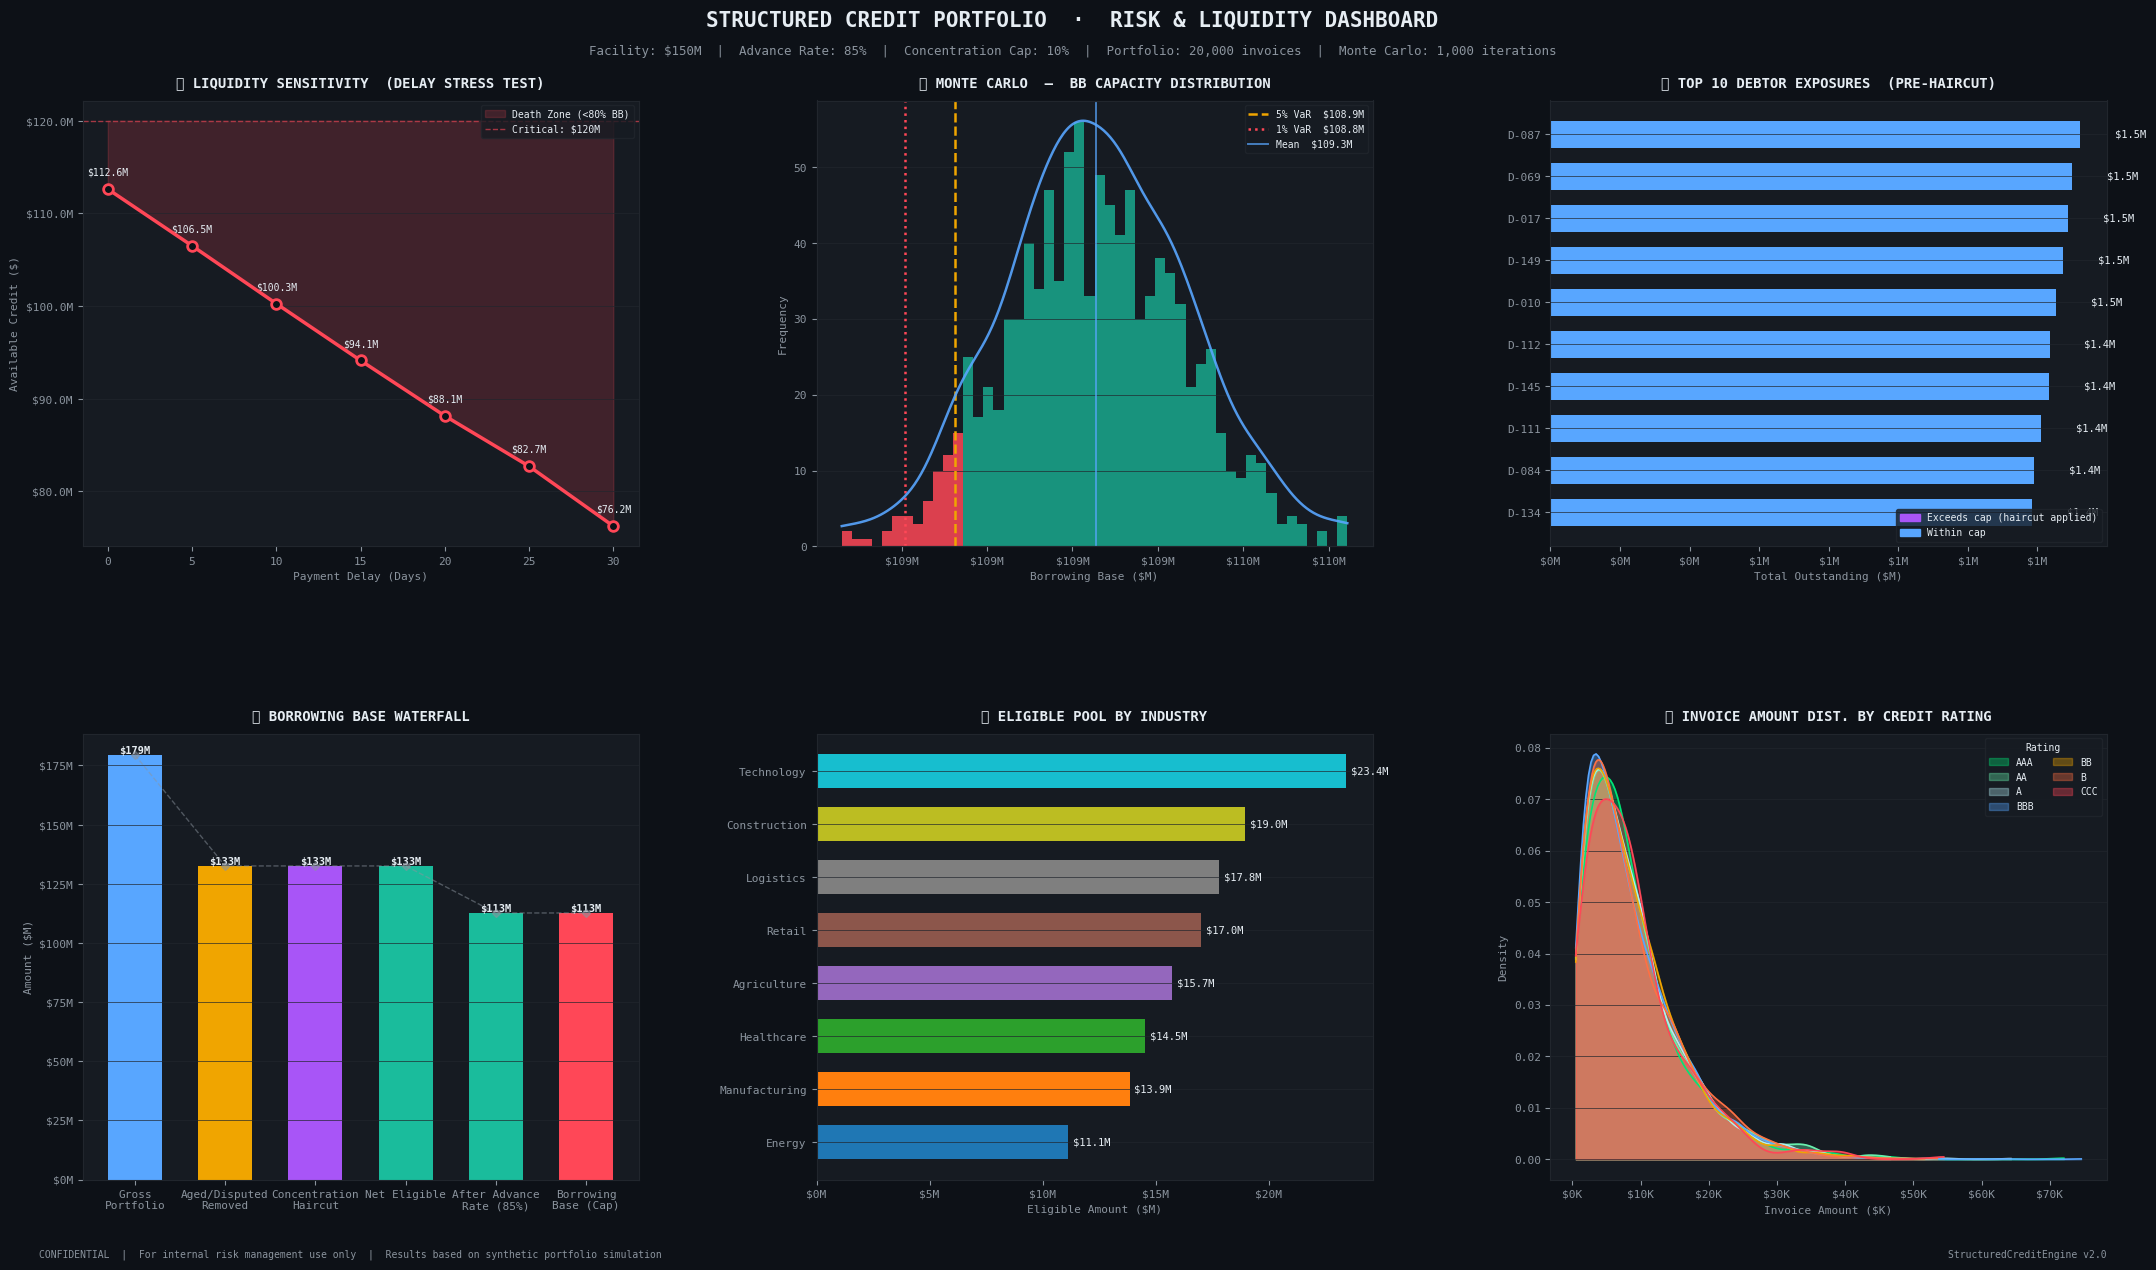

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — EXECUTIVE SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────────────────

def print_executive_summary(
    portfolio:    pd.DataFrame,
    base_result:  Dict[str, float],
    stress_df:    pd.DataFrame,
    risk_metrics: Dict[str, float],
    elapsed:      float,
) -> None:
    """Prints a formatted executive summary to stdout."""
    B  = "\033[1m"
    R  = "\033[0m"
    GR = "\033[92m"
    YL = "\033[93m"
    RD = "\033[91m"
    CY = "\033[96m"
    DI = "\033[2m"

    sep = "─" * 74
    rm  = risk_metrics
    br  = base_result

    print(f"\n{B}{'═'*74}{R}")
    print(f"{B}  STRUCTURED CREDIT PORTFOLIO  ·  EXECUTIVE RISK REPORT{R}")
    print(f"{B}{'═'*74}{R}\n")

    print(f"{CY}{B}  ① PORTFOLIO OVERVIEW{R}")
    print(f"  {sep}")
    print(f"  Total Records       : {len(portfolio):>12,}")
    print(f"  Gross Portfolio ($) : {portfolio['amount'].sum():>15,.0f}")
    print(f"  Disputed Invoices   : {portfolio['is_disputed'].sum():>12,}  "
          f"({portfolio['is_disputed'].mean()*100:.2f}%)")
    print(f"  Unique Debtors      : {portfolio['debtor_name'].nunique():>12,}")
    print(f"  Avg Invoice Amount  : ${portfolio['amount'].mean():>12,.0f}")
    print()

    print(f"{CY}{B}  ② BORROWING BASE (BASELINE){R}")
    print(f"  {sep}")
    elig_pct = br['eligible_count'] / br['total_count'] * 100
    hc_pct   = br['total_haircut'] / br['gross_eligible'] * 100 if br['gross_eligible'] else 0
    print(f"  Eligible Invoices   : {br['eligible_count']:>8,} / {br['total_count']:,}  ({elig_pct:.1f}%)")
    print(f"  Gross Eligible ($)  : {br['gross_eligible']:>15,.0f}")
    print(f"  Concentration HC($) : {br['total_haircut']:>15,.0f}  ({hc_pct:.1f}% of gross)")
    print(f"  Net Eligible ($)    : {br['gross_eligible']-br['total_haircut']:>15,.0f}")
    print(f"  BB Before Cap ($)   : {br['bb_before_cap']:>15,.0f}")
    print(f"  {GR}{B}Final Borrowing Base: ${br['borrowing_base']:>14,.0f}  "
          f"({br['utilisation_pct']:.1f}% utilisation){R}")
    print()

    print(f"{CY}{B}  ③ STRESS TEST RESULTS  (Systemic Payment Delay){R}")
    print(f"  {sep}")
    print(f"  {'Delay (Days)':<16} {'Borrowing Base ($)':<22} {'% of Baseline'}")
    baseline_bb = stress_df.iloc[0]["Borrowing_Base"]
    for _, row in stress_df.iterrows():
        pct   = row["Borrowing_Base"] / baseline_bb * 100 if baseline_bb else 0
        color = GR if pct >= 90 else (YL if pct >= 75 else RD)
        print(f"  {int(row['Delay_Days']):<16} "
              f"{color}${row['Borrowing_Base']:>18,.0f}{R}   "
              f"{color}{pct:>6.1f}%{R}")
    print()

    print(f"{CY}{B}  ④ MONTE CARLO  —  DEFAULT RISK METRICS  (1,000 iterations){R}")
    print(f"  {sep}")
    print(f"  Mean BB             : ${rm['mean_bb']:>15,.0f}")
    print(f"  Std Dev             : ${rm['std_bb']:>15,.0f}  ({rm['std_bb']/rm['mean_bb']*100:.1f}% CoV)")
    print(f"  {RD}5% Value-at-Risk    : ${rm['var_5pct']:>15,.0f}{R}")
    print(f"  {RD}1% Value-at-Risk    : ${rm['var_1pct']:>15,.0f}{R}")
    print(f"  {RD}5% CVaR (Tail Loss) : ${rm['cvar_5pct']:>15,.0f}{R}")
    print(f"  Min (Worst Case)    : ${rm['min_bb']:>15,.0f}")
    print(f"  Max (Best Case)     : ${rm['max_bb']:>15,.0f}")
    print(f"  Skewness            : {rm['skewness']:>16.4f}")
    print(f"  Excess Kurtosis     : {rm['kurtosis']:>16.4f}")
    print()

    print(f"{CY}{B}  ⑤ CONCENTRATION RISK  —  TOP 5 DEBTORS{R}")
    print(f"  {sep}")
    top5 = (portfolio.groupby("debtor_name")["amount"].sum()
            .sort_values(ascending=False).head(5))
    total_port = portfolio["amount"].sum()
    for debtor, amt in top5.items():
        share = amt / total_port * 100
        bar   = "█" * int(share * 2)
        print(f"  {debtor:<15}  ${amt:>10,.0f}  ({share:4.1f}%)  {bar}")
    print()

    print(f"{DI}  ⑥ ANALYSIS NOTES{R}")
    print(f"  {sep}")
    print(f"  • Invoices >90 days outstanding are ineligible per the Borrowing Base Agreement.")
    print(f"  • Concentration haircuts apply to debtors exceeding 10% of eligible pool.")
    print(f"  • Monte Carlo default probability: 3% per invoice (binomial, idiosyncratic).")
    print(f"  • Stress test applies uniform delay shift to all days_outstanding values.")
    print(f"  • 5% VaR represents the 1-in-20 adverse borrowing base scenario.")
    print()

    print(f"{B}{'═'*74}{R}")
    print(f"  Analysis completed in {elapsed:.2f}s")
    print(f"{B}{'═'*74}{R}\n")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN — ORCHESTRATION
# ─────────────────────────────────────────────────────────────────────────────

def main():
    t0 = time.time()

    print("\n[1/6] Generating synthetic trade finance portfolio (20,000 records)…")
    portfolio = generate_institutional_portfolio(n_records=20_000)
    print(f"      Done. Portfolio shape: {portfolio.shape}")

    print("[2/6] Initialising StructuredCreditEngine…")
    config = EngineConfig(
        facility_limit      = 150_000_000,
        advance_rate        = 0.85,
        concentration_cap   = 0.10,
        max_days_eligible   = 90,
        monte_carlo_iters   = 1_000,
        default_probability = 0.03,
        stress_max_delay    = 30,
        stress_step         = 5,
    )
    engine = StructuredCreditEngine(config=config)

    print("[3/6] Computing baseline Borrowing Base…")
    base_result = engine.compute_borrowing_base(portfolio)

    print("[4/6] Running Stress Test (payment delays 0–30 days)…")
    stress_df = engine.run_stress_test(portfolio)

    print("[5/6] Running Monte Carlo simulation (1,000 iterations)…")
    mc_results   = engine.run_monte_carlo(portfolio)
    risk_metrics = engine.compute_risk_metrics(mc_results)

    elapsed = time.time() - t0

    print("[6/6] Rendering dashboard & printing report…\n")
    print_executive_summary(portfolio, base_result, stress_df, risk_metrics, elapsed)

    plot_dashboard(engine, portfolio, base_result, stress_df, mc_results, risk_metrics)
    plot_correlation_heatmap(portfolio)


if __name__ == "__main__":
    main()